# Qwen3-4B B200 c_peak elbow curve

Notebook nay doc log benchmark JSON va truc quan hoa elbow curve theo `batch_size` vs `throughput`. Diem `c_peak` trong log duoc hieu la batch size nho nhat dat nguong throughput mong muon, mac dinh la 95% cua throughput cuc dai.

In [1]:
# Neu kernel chua co cac package nay, bo comment dong duoi va chay cell:
# %pip install pandas numpy matplotlib

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
LOG_PATH = Path("/Users/rcyuh/Downloads/qwen3_4b_b200_cpeak_c_peak.json")

with LOG_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

summary = raw.get("summary", {})
args = raw.get("args", {})
df = pd.DataFrame(raw["results"]).sort_values("batch_size").reset_index(drop=True)

df["latency_ms"] = df["latency_seconds"] * 1_000
df["throughput_delta"] = df["throughput"].diff()
df["batch_delta"] = df["batch_size"].diff()
df["marginal_tps_per_batch"] = df["throughput_delta"] / df["batch_delta"]
df["marginal_tps_per_batch_smooth"] = df["marginal_tps_per_batch"].rolling(5, center=True, min_periods=1).mean()

max_throughput = float(summary.get("max_throughput", df["throughput"].max()))
threshold = float(summary.get("threshold", 0.95))
threshold_throughput = float(summary.get("threshold_throughput", max_throughput * threshold))

first_above_threshold = df.loc[df["throughput"] >= threshold_throughput].head(1)
c_peak = int(summary.get("c_peak", first_above_threshold["batch_size"].iloc[0]))
c_peak_row = df.iloc[(df["batch_size"] - c_peak).abs().argmin()]
max_row = df.loc[df["throughput"].idxmax()]

display(pd.DataFrame([{
    "benchmark_mode": raw.get("benchmark_mode"),
    "recommend_metric": args.get("recommend_metric"),
    "points": len(df),
    "b_max": summary.get("b_max"),
    "step": summary.get("step"),
    "threshold": threshold,
    "c_peak": c_peak,
    "c_peak_throughput": c_peak_row["throughput"],
    "max_throughput": max_throughput,
    "max_batch_size": int(max_row["batch_size"]),
}]))

display(df.head())

,benchmark_mode,recommend_metric,points,b_max,step,threshold,c_peak,c_peak_throughput,max_throughput,max_batch_size
0,c_peak,generated_tokens_per_second,128,4096,32,0.95,2785,54174.424862,56744.133528,4001


,batch_size,latency_seconds,peak_memory_gb,status,throughput,latency_ms,throughput_delta,batch_delta,marginal_tps_per_batch,marginal_tps_per_batch_smooth
0,1,0.016688,7.553666,ok,59.924713,16.687606,NaN,NaN,NaN,59.110931
1,33,0.016929,7.567269,ok,1949.303177,16.929126,1889.378465,32.0,59.043077,58.869694
2,65,0.016914,7.580873,ok,3843.024298,16.913762,1893.721121,32.0,59.178785,59.668054
3,97,0.016984,7.594476,ok,5711.415368,16.983531,1868.391070,32.0,58.387221,59.229386
4,129,0.016759,7.608681,ok,7697.435637,16.758828,1986.020269,32.0,62.063133,59.456210


## Throughput elbow curve

Duong ngang la nguong throughput can dat. Duong doc `c_peak` danh dau batch size dau tien dat nguong nay.

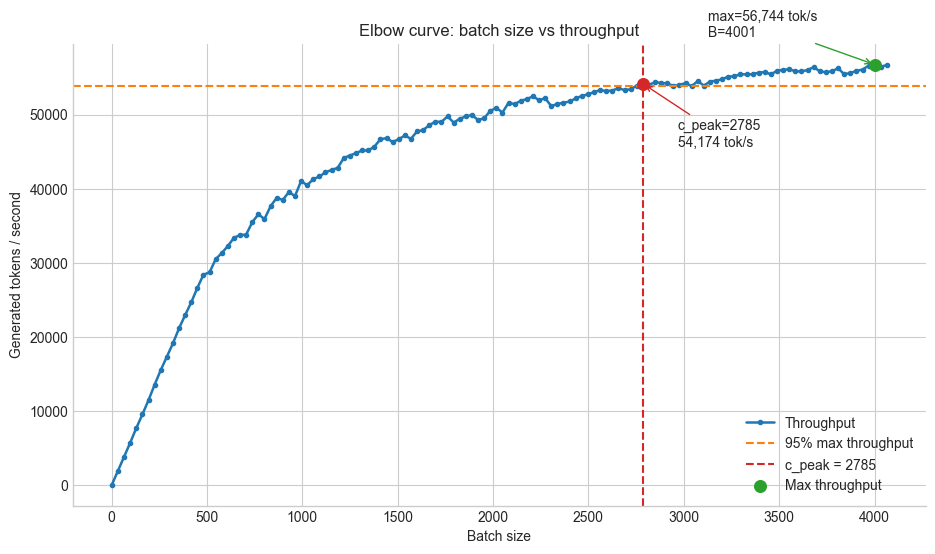

In [3]:
fig, ax = plt.subplots()

ax.plot(df["batch_size"], df["throughput"], marker="o", markersize=3, linewidth=1.8, label="Throughput")
ax.axhline(threshold_throughput, color="tab:orange", linestyle="--", linewidth=1.5, label=f"{threshold:.0%} max throughput")
ax.axvline(c_peak, color="tab:red", linestyle="--", linewidth=1.5, label=f"c_peak = {c_peak}")
ax.scatter([c_peak_row["batch_size"]], [c_peak_row["throughput"]], color="tab:red", s=70, zorder=5)
ax.scatter([max_row["batch_size"]], [max_row["throughput"]], color="tab:green", s=70, zorder=5, label="Max throughput")

ax.annotate(
    f"c_peak={c_peak}\n{c_peak_row['throughput']:,.0f} tok/s",
    xy=(c_peak_row["batch_size"], c_peak_row["throughput"]),
    xytext=(25, -45),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "tab:red"},
)
ax.annotate(
    f"max={max_row['throughput']:,.0f} tok/s\nB={int(max_row['batch_size'])}",
    xy=(max_row["batch_size"], max_row["throughput"]),
    xytext=(-120, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "tab:green"},
)

ax.set_title("Elbow curve: batch size vs throughput")
ax.set_xlabel("Batch size")
ax.set_ylabel("Generated tokens / second")
ax.legend(loc="lower right")
plt.show()

## Throughput gain per additional batch unit

Do thi nay giup nhin ro loi ich bien giam dan: khi marginal gain gan ve 0, tang batch size tiep se it dem lai throughput hon.

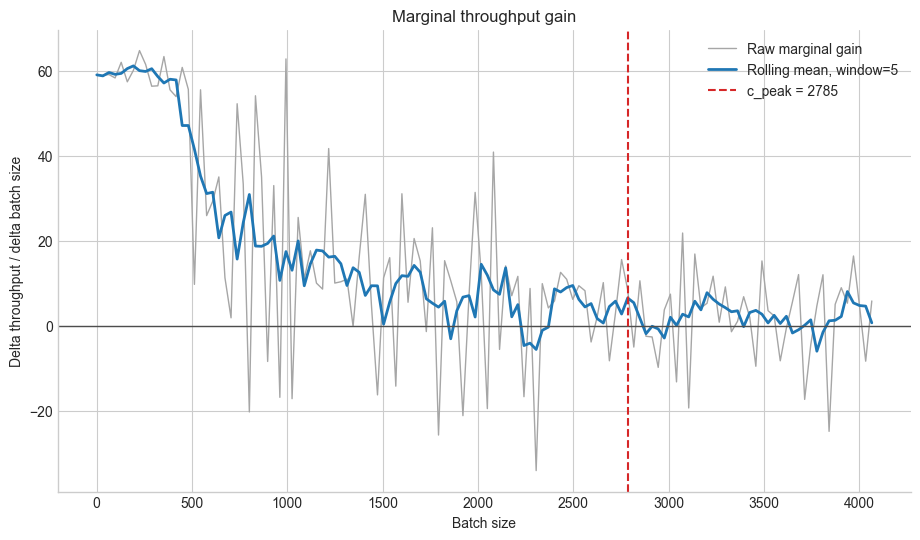

In [4]:
fig, ax = plt.subplots()

ax.plot(
    df["batch_size"],
    df["marginal_tps_per_batch"],
    color="0.65",
    linewidth=1,
    label="Raw marginal gain",
)
ax.plot(
    df["batch_size"],
    df["marginal_tps_per_batch_smooth"],
    color="tab:blue",
    linewidth=2,
    label="Rolling mean, window=5",
)
ax.axhline(0, color="0.3", linewidth=1)
ax.axvline(c_peak, color="tab:red", linestyle="--", linewidth=1.5, label=f"c_peak = {c_peak}")

ax.set_title("Marginal throughput gain")
ax.set_xlabel("Batch size")
ax.set_ylabel("Delta throughput / delta batch size")
ax.legend(loc="upper right")
plt.show()

## Latency and memory around the elbow

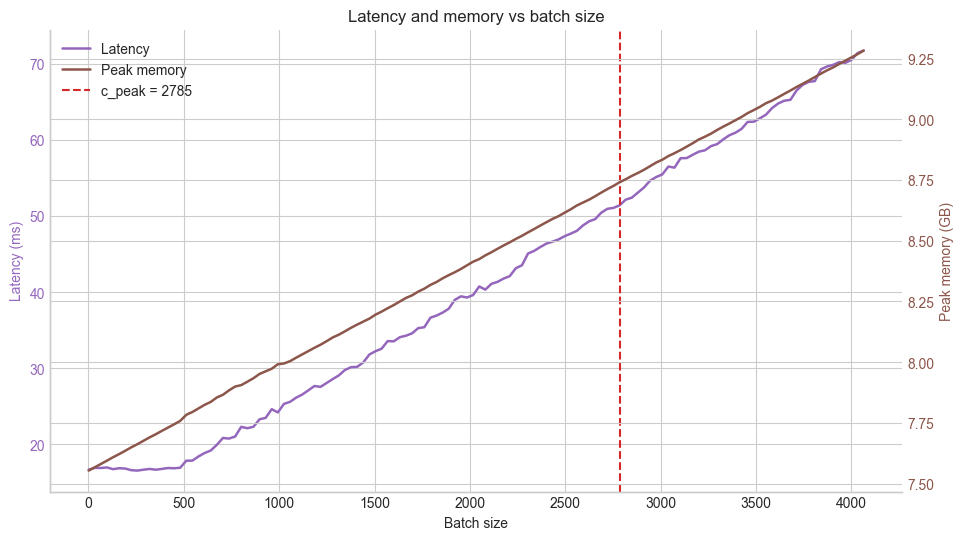

In [5]:
fig, ax1 = plt.subplots()

line1 = ax1.plot(df["batch_size"], df["latency_ms"], color="tab:purple", linewidth=1.8, label="Latency")
ax1.set_xlabel("Batch size")
ax1.set_ylabel("Latency (ms)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple")
ax1.axvline(c_peak, color="tab:red", linestyle="--", linewidth=1.5, label=f"c_peak = {c_peak}")

ax2 = ax1.twinx()
line2 = ax2.plot(df["batch_size"], df["peak_memory_gb"], color="tab:brown", linewidth=1.8, label="Peak memory")
ax2.set_ylabel("Peak memory (GB)", color="tab:brown")
ax2.tick_params(axis="y", labelcolor="tab:brown")

lines = line1 + line2 + [ax1.lines[-1]]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")
ax1.set_title("Latency and memory vs batch size")
plt.show()

## Geometric elbow reference

Cell nay tinh mot elbow hinh hoc bang khoang cach lon nhat tu duong noi diem dau-cuoi tren du lieu da normalize. Day chi la tham khao de so sanh voi `c_peak` theo nguong 95%.

/var/folders/k1/h2c4n6pd5wd_slt7g7j1v5j00000gn/T/ipykernel_20158/621638489.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line_vec, points - start) / np.linalg.norm(line_vec))


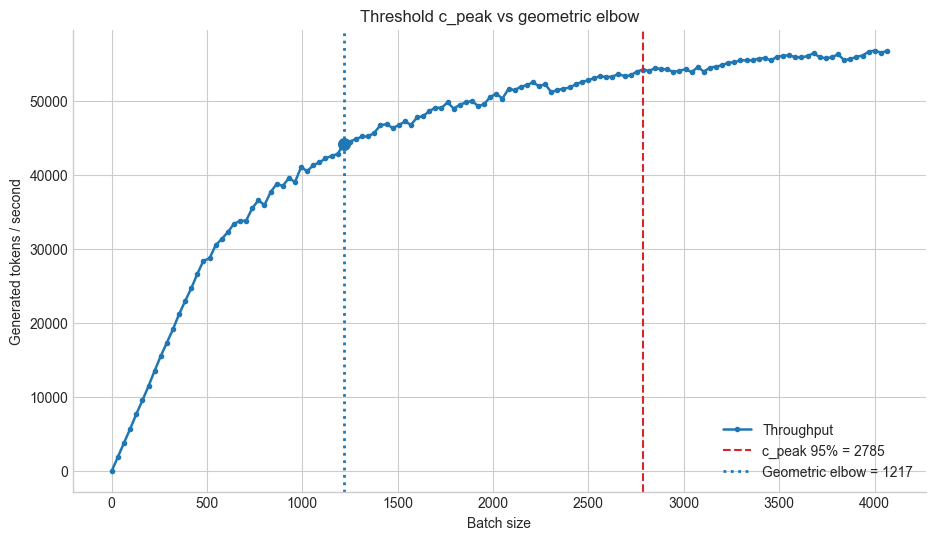

,method,batch_size,throughput,throughput_pct_of_max,latency_ms,peak_memory_gb
0,c_peak threshold,2785,54174.424862,0.954714,51.408022,8.740693
1,geometric elbow,1217,44143.040990,0.777931,27.569464,8.072008
2,max throughput,4001,56744.133528,1.000000,70.509491,9.254836


In [6]:
x = df["batch_size"].to_numpy(dtype=float)
y = df["throughput"].to_numpy(dtype=float)
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())
points = np.column_stack([x_norm, y_norm])

start = points[0]
end = points[-1]
line_vec = end - start
distances = np.abs(np.cross(line_vec, points - start) / np.linalg.norm(line_vec))
geo_elbow_idx = int(distances.argmax())
geo_elbow_row = df.iloc[geo_elbow_idx]

fig, ax = plt.subplots()
ax.plot(df["batch_size"], df["throughput"], marker="o", markersize=3, linewidth=1.8, label="Throughput")
ax.axvline(c_peak, color="tab:red", linestyle="--", linewidth=1.5, label=f"c_peak 95% = {c_peak}")
ax.axvline(geo_elbow_row["batch_size"], color="tab:blue", linestyle=":", linewidth=2, label=f"Geometric elbow = {int(geo_elbow_row['batch_size'])}")
ax.scatter([geo_elbow_row["batch_size"]], [geo_elbow_row["throughput"]], color="tab:blue", s=70, zorder=5)

ax.set_title("Threshold c_peak vs geometric elbow")
ax.set_xlabel("Batch size")
ax.set_ylabel("Generated tokens / second")
ax.legend(loc="lower right")
plt.show()

display(pd.DataFrame([
    {
        "method": "c_peak threshold",
        "batch_size": int(c_peak_row["batch_size"]),
        "throughput": c_peak_row["throughput"],
        "throughput_pct_of_max": c_peak_row["throughput"] / max_throughput,
        "latency_ms": c_peak_row["latency_ms"],
        "peak_memory_gb": c_peak_row["peak_memory_gb"],
    },
    {
        "method": "geometric elbow",
        "batch_size": int(geo_elbow_row["batch_size"]),
        "throughput": geo_elbow_row["throughput"],
        "throughput_pct_of_max": geo_elbow_row["throughput"] / max_throughput,
        "latency_ms": geo_elbow_row["latency_ms"],
        "peak_memory_gb": geo_elbow_row["peak_memory_gb"],
    },
    {
        "method": "max throughput",
        "batch_size": int(max_row["batch_size"]),
        "throughput": max_row["throughput"],
        "throughput_pct_of_max": max_row["throughput"] / max_throughput,
        "latency_ms": max_row["latency_ms"],
        "peak_memory_gb": max_row["peak_memory_gb"],
    },
]))

## Inspect points near c_peak

In [7]:
window = int(summary.get("step", 32)) * 4
near_elbow = df.loc[df["batch_size"].between(c_peak - window, c_peak + window)].copy()
near_elbow["throughput_pct_of_max"] = near_elbow["throughput"] / max_throughput

display(
    near_elbow[[
        "batch_size",
        "throughput",
        "throughput_pct_of_max",
        "latency_ms",
        "peak_memory_gb",
        "marginal_tps_per_batch",
    ]].style.format({
        "throughput": "{:,.2f}",
        "throughput_pct_of_max": "{:.2%}",
        "latency_ms": "{:.2f}",
        "peak_memory_gb": "{:.2f}",
        "marginal_tps_per_batch": "{:.2f}",
    })
)

AttributeError: The '.style' accessor requires jinja2